<a href="https://colab.research.google.com/github/sravan277/imageClassifier/blob/main/imageClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow opencv-python matplotlib

In [1]:
import tensorflow as tf
import os


In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

remove dodgy images

In [4]:
import cv2
import matplotlib.pyplot as plt
import imghdr

In [5]:
data_dir = '/content/drive/MyDrive/image_classifier'

In [6]:
image_exts = ['jpg', 'jpeg', 'bmp', 'png']
os.listdir(data_dir)

['puppy', 'kittens']

In [7]:

img = cv2.imread(os.path.join(data_dir, 'puppy', 'puppy-sleeping-16x9.jpg'))

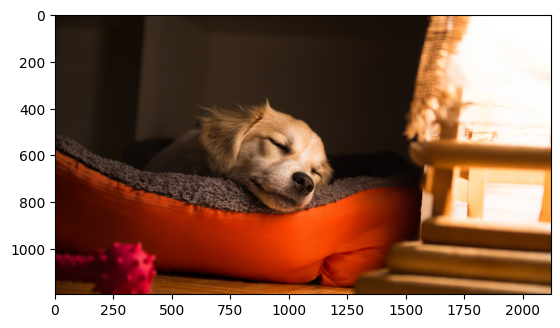

In [8]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


In [9]:
for image_class in os.listdir(data_dir):
  for image in os.listdir(os.path.join(data_dir, "puppy")):
    image_path = os.path.join(data_dir, "puppy", image)
    try:
      img = cv2.imread(image_path)
      tip = imghdr.what(image_path)
      if tip not in image_exts:
        print("image does not exist in {}".format(image_path))
        os.remove(image_path)
    except Exception as e:
      print("issue with image {}".format(image_path))
      os.remove(image_path)

load data


In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data = tf.keras.utils.image_dataset_from_directory(data_dir)

Found 220 files belonging to 2 classes.


In [ ]:
data_iter = data.as_numpy_iterator()

In [ ]:
batch = data_iter.next()


In [ ]:
batch[0].shape

(32, 256, 256, 3)

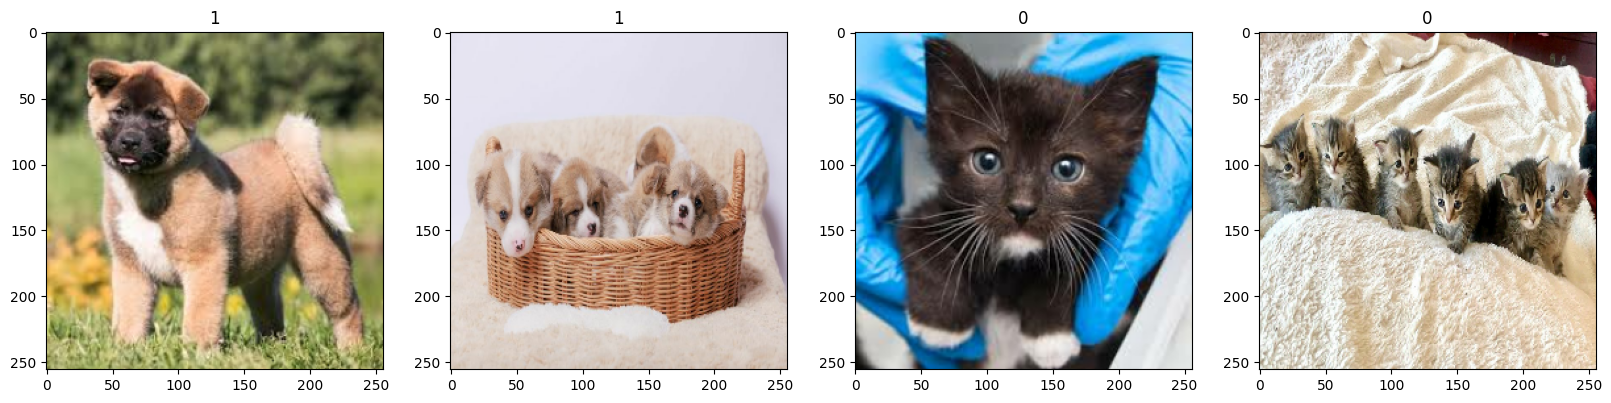

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
  ax[idx].imshow(img.astype(int))
  ax[idx].title.set_text(batch[1][idx])

preprossing


In [12]:
data = data.map(lambda x, y: (x/255, y))

In [13]:
batch = data.as_numpy_iterator().next()

In [14]:
batch[0].max()

1.0

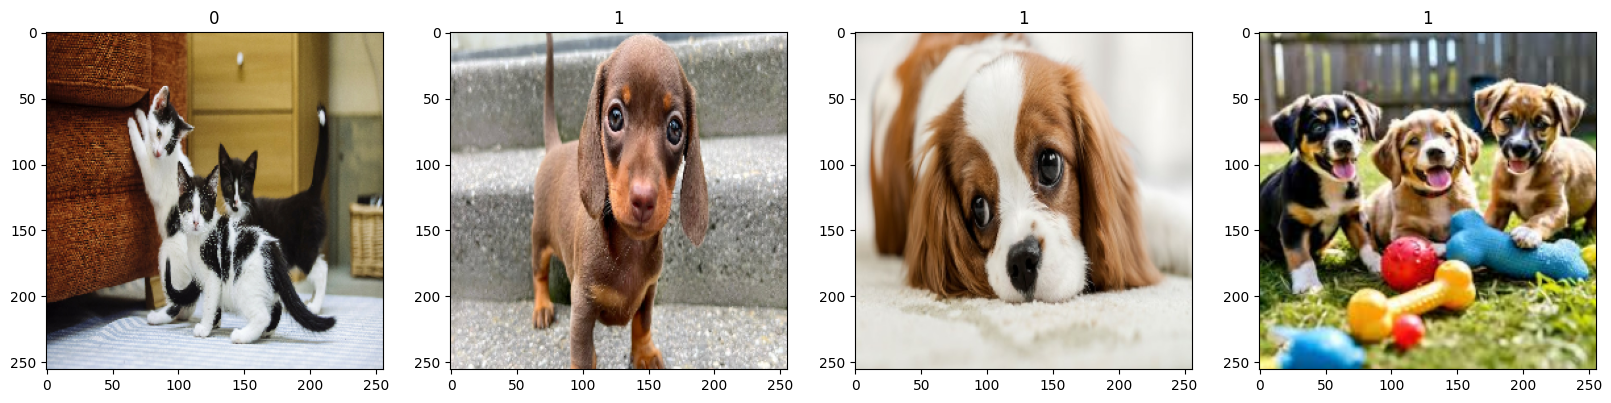

In [15]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
  ax[idx].imshow(img)
  ax[idx].title.set_text(batch[1][idx])

split data

In [16]:
len(data)

7

In [17]:
train_data = int(len(data)*.7)
val_data = int(len(data)*.2)+1
test_data = int(len(data)*.1)+1

In [18]:
train = data.take(train_data)
val = data.skip(train_data).take(val_data)
test = data.skip(train_data).skip(val_data).take(test_data)

In [25]:
batch[0].shape

(32, 256, 256, 3)

building deep learning model

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [26]:
model = Sequential()
model.add(Conv2D(16, (3, 3), 1, activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D())


model.add(Conv2D(32, (3, 3), 1, activation='relu'))
model.add(MaxPooling2D())


model.add(Conv2D(16, (3, 3), 1, activation='relu'))
model.add(MaxPooling2D())


model.add(Flatten())


model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

train

In [29]:
logdir = 'logs'

In [30]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [31]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.5312 - loss: 0.8023 - val_accuracy: 0.5312 - val_loss: 0.6777
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5365 - loss: 0.6702 - val_accuracy: 0.5625 - val_loss: 0.6517
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.5479 - loss: 0.6367 - val_accuracy: 0.7812 - val_loss: 0.5795
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.6208 - loss: 0.6316 - val_accuracy: 0.7031 - val_loss: 0.5662
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6802 - loss: 0.5924 - val_accuracy: 0.7969 - val_loss: 0.5467
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.8260 - loss: 0.5261 - val_accuracy: 0.7500 - val_loss: 0.4820
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.7854 - loss: 0.4841 - val_accuracy: 0.7188 - val_loss: 0.5061
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.7625 - loss: 0.4178 - val_accuracy: 0.8125 - val_loss: 0.4238
Epoch 9/

figure plot

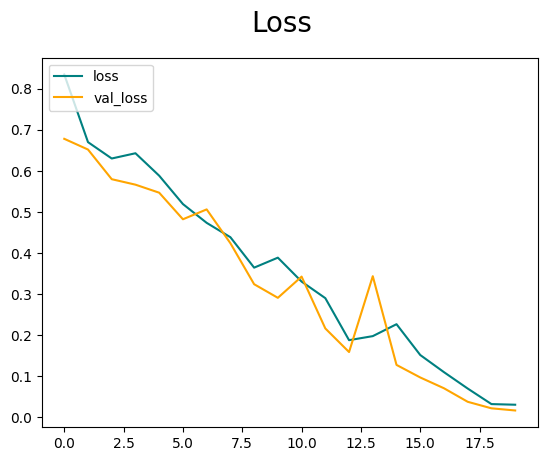

In [32]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

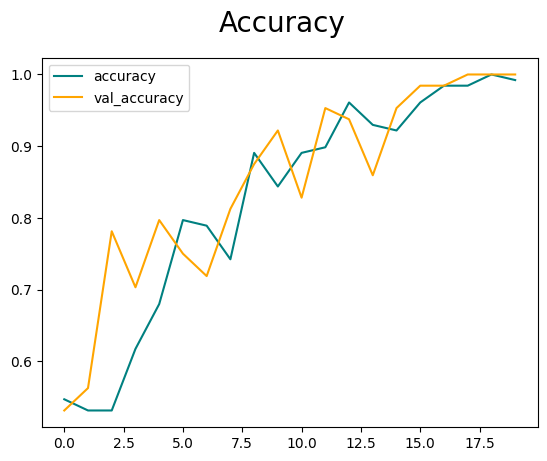

In [33]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

evaluate performance

In [34]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [35]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [36]:
for batch in test.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  pre.update_state(y, yhat)
  re.update_state(y, yhat)
  acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step


In [39]:
print(pre.result().numpy(), re.result().numpy(), acc.result().numpy())

1.0 1.0 1.0


test

In [40]:
import cv2

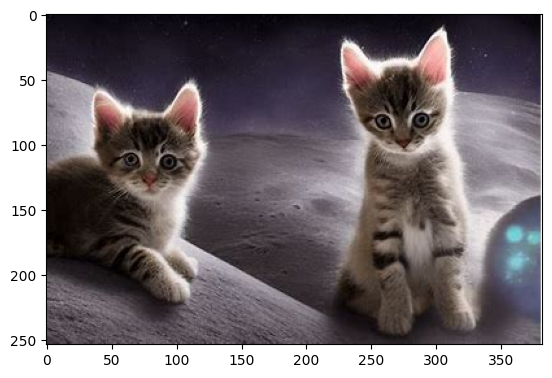

In [50]:
img = cv2.imread('/content/drive/MyDrive/kitten.jpeg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

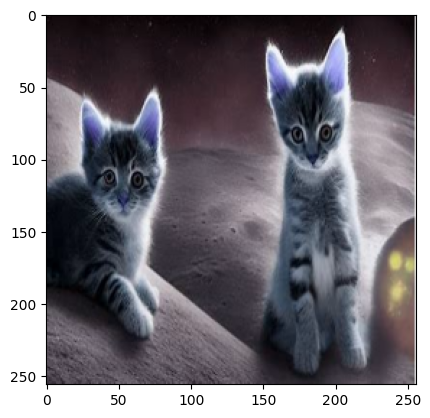

In [51]:
resize = tf.image.resize(img, (256, 256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [52]:
resize.shape

TensorShape([256, 256, 3])

In [53]:
np.expand_dims(resize, 0)

array([[[[ 15.769531 ,   6.7695312,   9.769531 ],
         [ 17.90625  ,   8.90625  ,  11.90625  ],
         [ 35.695312 ,  26.695312 ,  29.695312 ],
         ...,
         [ 11.769531 ,   6.7695312,   8.769531 ],
         [ 11.738281 ,   7.2617188,   9.261719 ],
         [194.95312  , 191.95312  , 193.95312  ]],

        [[ 25.652344 ,  16.652344 ,  19.652344 ],
         [ 24.870544 ,  15.870544 ,  18.870544 ],
         [ 34.251495 ,  25.251495 ,  28.251495 ],
         ...,
         [ 11.769531 ,   6.7695312,   8.769531 ],
         [ 11.738281 ,   7.2617188,   9.261719 ],
         [194.95312  , 191.95312  , 193.95312  ]],

        [[ 13.747299 ,   4.747299 ,   7.747299 ],
         [ 14.424576 ,   5.424576 ,   8.424576 ],
         [ 19.676712 ,  10.676712 ,  13.676712 ],
         ...,
         [ 11.769531 ,   6.7695312,   8.769531 ],
         [ 11.738281 ,   7.2617188,   9.261719 ],
         [194.95312  , 191.95312  , 193.95312  ]],

        ...,

        [[ 72.561005 ,  64.561005 ,  7

In [54]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [55]:
yhat

array([[0.00409311]], dtype=float32)

In [56]:
if yhat > 0.5:
  print(f'predicted class is puppy')
else:
  print(f'predicted class is kitten')

predicted class is kitten
